# Notebook 04: **Single-Frame Semantic Reflectivity Analysis**

---

## 1. Purpose of This Notebook

Notebook 01 established that the SemanticKITTI data-loading pipeline is correct and numerically trustworthy. Notebook 02 showed that, on a single frame, a simple range-aware pseudo-reflectivity proxy can become more semantically informative than raw intensity alone. Notebook 03 then tested whether that signal remains structured and stable across short motion windows.

Now we zoom into the semantic side directly.

The purpose of Notebook 04 is to study, on one LiDAR frame with semantic labels, how raw intensity and pseudo-reflectivity behave **class by class**. This notebook is where we stop looking only at global signal statistics and ask a more targeted question:

**Do different semantic classes exhibit different reflectivity-style signatures, and does the pseudo-reflectivity proxy reveal those class-wise differences more clearly than raw intensity?**

This is still an analysis notebook, not a trained segmentation notebook. The goal is not to build a semantic model here. The goal is to produce a clean semantic interpretation of the signal.

## 2. Conceptual Motivation

A LiDAR point cloud gives us:
- geometry through spatial coordinates,
- return strength through intensity,
- and semantic meaning through labels.

Each point can be written as:

$$
p_i = (x_i, y_i, z_i, I_i, y_i^{(sem)})
$$

where:
- $(x_i, y_i, z_i)$ are 3D coordinates,
- $I_i$ is raw LiDAR intensity,
- $y_i^{(sem)}$ is the semantic class label.

The central issue is that raw intensity is not a pure material cue. It is entangled with range and incidence geometry. The uploaded paper makes exactly this point: raw intensity depends on reflectivity, range, and incidence angle, while calibrated reflectivity is more consistent and interpretable for semantic segmentation.

Since we do not have full calibration terms available in this project scope, we continue using the same practical proxy as before:

$$
\hat{\rho}_i = I_i \cdot R_i
$$

This is **not** true calibrated reflectivity. It is only a heuristic range-aware feature. But Notebook 02 already showed that this proxy improved single-frame class separability relative to raw intensity, so Notebook 04 now asks whether that effect can be understood more explicitly at the semantic-class level.

## 3. Mathematical Model Used in This Notebook

### 3.1 Point Representation

Each LiDAR point is represented as:

$$
p_i = (x_i, y_i, z_i, I_i)
$$

with a corresponding semantic label:

$$
s_i \in \mathcal{C}
$$

where $\mathcal{C}$ is the set of semantic classes present in the frame.

### 3.2 Range

For each point, we compute Euclidean range:

$$
R_i = \sqrt{x_i^2 + y_i^2 + z_i^2}
$$

### 3.3 Practical Signal Interpretation

A simplified LiDAR return model is:

$$
I_i \propto \frac{\rho_i \cos(\alpha_i)}{R_i^2}
$$

where:
- $\rho_i$ is surface reflectivity,
- $\alpha_i$ is incidence angle,
- \(R_i$ is range.

This means raw intensity mixes semantic surface properties with geometric measurement effects. The paper argues that calibrated reflectivity provides a better representation than raw intensity for segmentation because it is less entangled with range and incidence angle.

### 3.4 Pseudo-Reflectivity Approximation

Because full calibration is outside the scope of this notebook, we use:

$$
\hat{\rho}_i = I_i \cdot R_i
$$

We keep the honesty clause fully intact:

- $\hat{\rho}$ is **not** calibrated reflectivity,
- it is a practical range-aware proxy,
- its value lies in interpretability, not physical exactness.

## 4. What This Notebook Will Do

This notebook follows the same disciplined structure as the earlier ones.

### Step A: Reload one verified SemanticKITTI frame

We will reuse the validated pipeline from Notebook 01 and the same single-frame setup style from Notebook 02.

### Step B: Recover the core signals
For the selected frame, we will extract:
- coordinates $(x, y, z)$,
- raw intensity $I$,
- range $R$,
- pseudo-reflectivity $\hat{\rho} = I \cdot R$,
- semantic labels.

### Step C: Identify valid semantic classes
We will inspect which semantic classes appear in the frame and optionally restrict analysis to classes with enough support, so that class-wise statistics are meaningful rather than noisy.

### Step D: Compute class-wise signal summaries
For each valid semantic class, we will compute descriptive statistics for:
- raw intensity,
- pseudo-reflectivity,
- range.

This gives a per-class view of how the signal behaves semantically.

### Step E: Compare class-wise distributions visually
We will generate plots such as:
- class-wise histograms of raw intensity,
- class-wise histograms of pseudo-reflectivity,
- summary bar plots of per-class means or medians.

### Step F: Build semantic visualizations in space
We will visualize the frame spatially using semantic labels, and compare those semantics against intensity and pseudo-reflectivity views in the same frame.

### Step G: Quantify class separability again
Using the same Fisher-style separability logic from Notebook 02, we will measure whether pseudo-reflectivity is more semantically discriminative than raw intensity on this frame. This keeps the methodology consistent instead of inventing a new metric just for drama.

## 5. What We Are Trying to Achieve

This notebook has a very specific role in the project plan.

We want to achieve four things:

1. **Attach signal analysis directly to semantics**  
   Not just “the histogram looks different,” but “this class behaves differently from that class.”

2. **Interpret the earlier separability result**  
   Notebook 02 showed improved class separability numerically. Notebook 04 should help explain *why* that happens.

3. **Produce a semantic glimpse without overselling scope**  
   The planning note explicitly recommended that the early semantic stage stay small and disciplined: attach semantics to one frame, show alignment, and interpret it carefully rather than pretending a full semantic system already exists.

4. **Prepare for stronger semantic analysis later**  
   If class-wise behavior looks meaningful here, then later work can scale that idea through motion or into a modular perception pipeline.

## 6. What We Expect to Show

By the end of this notebook, we expect to show that:

- semantic labels are correctly aligned with the selected frame,
- different classes exhibit distinguishable raw-intensity behavior,
- pseudo-reflectivity changes those class-wise distributions in a meaningful way,
- some classes become more separable under pseudo-reflectivity than under raw intensity,
- and the resulting interpretation is strong enough to justify later semantic analysis through motion.

If the notebook behaves well, the final takeaway should be something like this:

**Raw intensity already contains some semantic information, but a simple range-aware pseudo-reflectivity proxy can reshape that information into a more interpretable class-wise signal for at least part of the scene.**

That would be a clean, honest, and useful result.

## 7. Expected Outputs

This notebook should end with a compact but meaningful semantic analysis package:

- one verified labeled LiDAR frame,
- class counts for the frame,
- class-wise summary statistics for intensity and pseudo-reflectivity,
- class-wise histograms,
- spatial semantic plots,
- a final class-separability comparison,
- and a short interpretation block explaining what the semantics seem to be doing.

## 8. Honesty Note

This notebook does **not** claim:
- true reflectivity calibration,
- a trained semantic segmentation method,
- universally superior performance of pseudo-reflectivity,
- or geometry-invariant reflectance recovery.

It is a **single-frame semantic signal-analysis notebook**.

That is exactly the right scope for this stage of the project: small, sharp, defensible, and actually useful.

## Step 1: Reload one verified semantic frame and recover the core signals

We begin by reusing the same verified SemanticKITTI frame setup from the earlier notebooks.

In this step, we only rebuild the clean starting state for Notebook 04:
- load one LiDAR frame,
- load its matching semantic labels,
- confirm point-label alignment,
- extract the raw channels,
- compute range,
- and compute the same pseudo-reflectivity proxy used earlier: `I * R`.

No class-wise semantic analysis yet.
No plots yet.
Right now we are just assembling the ingredients so the semantic breakdown in the next step does not start from cursed soup.

In [1]:
from pathlib import Path
import numpy as np

# Notebook is assumed to run from notebooks/
DATASET_ROOT = Path("../data/semantickitti_subset/dataset/sequences/00")
FRAME_ID = "000000"

bin_path = DATASET_ROOT / "velodyne" / f"{FRAME_ID}.bin"
label_path = DATASET_ROOT / "labels" / f"{FRAME_ID}.label"

# Load point cloud and labels
points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
labels = np.fromfile(label_path, dtype=np.uint32)

# Raw channels
xyz = points[:, :3]
intensity = points[:, 3]
ranges = np.linalg.norm(xyz, axis=1)

# Same proxy used in Notebook 02 and carried into Notebook 03
pseudo_reflectivity = intensity * ranges

# Unpack labels
semantic_labels = labels & 0xFFFF
instance_labels = labels >> 16

# Structural sanity checks
print("FRAME ID:", FRAME_ID)
print("Point cloud shape       :", points.shape)
print("Labels shape            :", labels.shape)
print("XYZ shape               :", xyz.shape)
print("Intensity shape         :", intensity.shape)
print("Ranges shape            :", ranges.shape)
print("Pseudo-reflectivity     :", pseudo_reflectivity.shape)
print("Semantic labels shape   :", semantic_labels.shape)
print("Instance labels shape   :", instance_labels.shape)
print()

print("Point-label aligned     :", len(points) == len(labels))
print()

print("First 3 points:")
print(points[:3])
print()

print("First 10 semantic labels:")
print(semantic_labels[:10])
print()

print("First 10 instance labels:")
print(instance_labels[:10])
print()

print("Quick signal sanity:")
print(f"  intensity mean        : {intensity.mean():.6f}")
print(f"  range mean            : {ranges.mean():.6f}")
print(f"  pseudo-reflectivity mean: {pseudo_reflectivity.mean():.6f}")

FRAME ID: 000000
Point cloud shape       : (124668, 4)
Labels shape            : (124668,)
XYZ shape               : (124668, 3)
Intensity shape         : (124668,)
Ranges shape            : (124668,)
Pseudo-reflectivity     : (124668,)
Semantic labels shape   : (124668,)
Instance labels shape   : (124668,)

Point-label aligned     : True

First 3 points:
[[5.2897942e+01 2.2989739e-02 1.9979945e+00 7.9999998e-02]
 [5.3750526e+01 1.9291429e-01 2.0269539e+00 0.0000000e+00]
 [5.3803116e+01 3.6183926e-01 2.0289137e+00 0.0000000e+00]]

First 10 semantic labels:
[0 0 0 0 0 0 0 0 0 0]

First 10 instance labels:
[0 0 0 0 0 0 0 0 0 0]

Quick signal sanity:
  intensity mean        : 0.294134
  range mean            : 13.565046
  pseudo-reflectivity mean: 3.628692


## Step 2: Inspect which semantic classes exist in this frame

Now that the frame is loaded correctly, we check the semantic composition of the scene.

In this step, we will:
- list all semantic class IDs present,
- count how many points belong to each class,
- and identify which classes are large enough to support meaningful class-wise signal analysis.

This gives us the semantic battlefield before we start comparing intensity and pseudo-reflectivity class by class.

In [2]:
import numpy as np

unique_classes, class_counts = np.unique(semantic_labels, return_counts=True)

print("Number of unique semantic classes in frame:", len(unique_classes))
print()

print("Semantic class counts:")
for cls, cnt in zip(unique_classes, class_counts):
    print(f"Class {cls:>3}: {cnt}")

# Optional support threshold for later class-wise analysis
MIN_POINTS_PER_CLASS = 500

valid_classes = unique_classes[class_counts >= MIN_POINTS_PER_CLASS]
valid_counts = class_counts[class_counts >= MIN_POINTS_PER_CLASS]

print()
print(f"Classes with at least {MIN_POINTS_PER_CLASS} points:")
for cls, cnt in zip(valid_classes, valid_counts):
    print(f"Class {cls:>3}: {cnt}")

print()
print("Valid class IDs for downstream analysis:")
print(valid_classes.tolist())

Number of unique semantic classes in frame: 17

Semantic class counts:
Class   0: 2184
Class   1: 4
Class  10: 4234
Class  40: 34228
Class  44: 3268
Class  48: 26360
Class  50: 18268
Class  51: 370
Class  52: 1471
Class  60: 1053
Class  70: 27123
Class  71: 1192
Class  72: 2964
Class  80: 532
Class  81: 102
Class  99: 1227
Class 255: 88

Classes with at least 500 points:
Class   0: 2184
Class  10: 4234
Class  40: 34228
Class  44: 3268
Class  48: 26360
Class  50: 18268
Class  52: 1471
Class  60: 1053
Class  70: 27123
Class  71: 1192
Class  72: 2964
Class  80: 532
Class  99: 1227

Valid class IDs for downstream analysis:
[0, 10, 40, 44, 48, 50, 52, 60, 70, 71, 72, 80, 99]


## Step 3: Build class-wise summary statistics for the core signals

Now we move from semantic presence to semantic signal behavior.

In this step, for each sufficiently populated class, we will compute compact descriptive statistics for:
- raw intensity,
- range,
- and pseudo-reflectivity.

This tells us whether different semantic classes occupy different signal regimes before we even start plotting distributions.

In [3]:
import pandas as pd
import numpy as np

rows = []

for cls in valid_classes:
    mask = semantic_labels == cls

    cls_intensity = intensity[mask]
    cls_ranges = ranges[mask]
    cls_pseudo = pseudo_reflectivity[mask]

    rows.append({
        "class_id": int(cls),
        "count": int(mask.sum()),

        "intensity_mean": float(np.mean(cls_intensity)),
        "intensity_std": float(np.std(cls_intensity)),
        "intensity_p25": float(np.percentile(cls_intensity, 25)),
        "intensity_p50": float(np.percentile(cls_intensity, 50)),
        "intensity_p75": float(np.percentile(cls_intensity, 75)),

        "range_mean": float(np.mean(cls_ranges)),
        "range_std": float(np.std(cls_ranges)),
        "range_p25": float(np.percentile(cls_ranges, 25)),
        "range_p50": float(np.percentile(cls_ranges, 50)),
        "range_p75": float(np.percentile(cls_ranges, 75)),

        "pseudo_mean": float(np.mean(cls_pseudo)),
        "pseudo_std": float(np.std(cls_pseudo)),
        "pseudo_p25": float(np.percentile(cls_pseudo, 25)),
        "pseudo_p50": float(np.percentile(cls_pseudo, 50)),
        "pseudo_p75": float(np.percentile(cls_pseudo, 75)),
    })

class_stats_df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

print("Class-wise summary statistics:")
display(class_stats_df)

Class-wise summary statistics:


,class_id,count,intensity_mean,intensity_std,intensity_p25,intensity_p50,intensity_p75,range_mean,range_std,range_p25,range_p50,range_p75,pseudo_mean,pseudo_std,pseudo_p25,pseudo_p50,pseudo_p75
0,40,34228,0.213374,0.113441,0.16,0.25,0.29,9.779534,6.546706,5.605285,7.266638,11.138959,1.895020,1.460192,1.022925,1.712127,2.432171
1,70,27123,0.333848,0.131191,0.27,0.34,0.41,16.486662,10.300393,8.144478,13.146496,21.098911,4.861657,2.745001,2.819527,4.443832,6.407302
2,48,26360,0.300424,0.079737,0.28,0.31,0.35,8.518487,5.227359,5.460627,6.657840,9.428081,2.472348,1.448439,1.640431,2.077798,2.861552
3,50,18268,0.428269,0.148804,0.34,0.42,0.52,15.399200,6.694814,10.730637,13.061844,17.301601,6.293034,2.691933,4.419292,6.030804,8.061449
4,10,4234,0.153462,0.193044,0.00,0.09,0.27,14.442315,9.118223,8.085788,8.730825,21.078747,2.553735,4.030944,0.000000,0.784169,3.145671
5,44,3268,0.299865,0.085356,0.27,0.32,0.35,13.468061,7.984953,8.016994,9.541819,18.266766,3.833581,2.288389,2.387962,3.068133,5.064581
6,72,2964,0.311606,0.115178,0.25,0.33,0.39,22.927259,9.109071,15.432064,20.181004,28.056694,6.411902,2.519396,5.051509,6.313788,7.673467
7,0,2184,0.047019,0.116439,0.00,0.00,0.00,59.040615,11.136915,54.508484,57.576302,64.999191,2.567785,6.472702,0.000000,0.000000,0.000000
8,52,1471,0.344582,0.159827,0.26,0.36,0.45,13.619083,6.919503,10.642494,10.746443,10.884012,4.121638,2.271700,3.090988,4.062512,5.139290
9,99,1227,0.279446,0.155952,0.20,0.31,0.38,21.013813,12.509447,9.031216,16.166605,37.970516,4.727847,3.791297,2.697250,3.680454,6.416998


The class-wise summary table already shows that different semantic classes occupy different signal regimes.

A few early patterns stand out:
- some classes have low raw intensity but nontrivial pseudo-reflectivity, suggesting range interaction changes their signal profile,
- some classes remain strong in both raw intensity and pseudo-reflectivity,
- and some classes appear weak or sparse, which is why a minimum-point threshold was necessary.

So even before plotting distributions, the table suggests that pseudo-reflectivity is not behaving like a trivial rescaling of intensity. It is redistributing the semantic signal in a class-dependent way.

## Step 4: Compare class-wise distributions with boxplots

Summary statistics are useful, but they can hide the actual spread and overlap of each class.

In this step, we visualize class-wise distributions for:
- raw intensity, and
- pseudo-reflectivity.

using boxplots across the valid semantic classes.

This helps us see whether the pseudo-reflectivity proxy separates classes more cleanly or just inflates the same soup in a larger bowl.

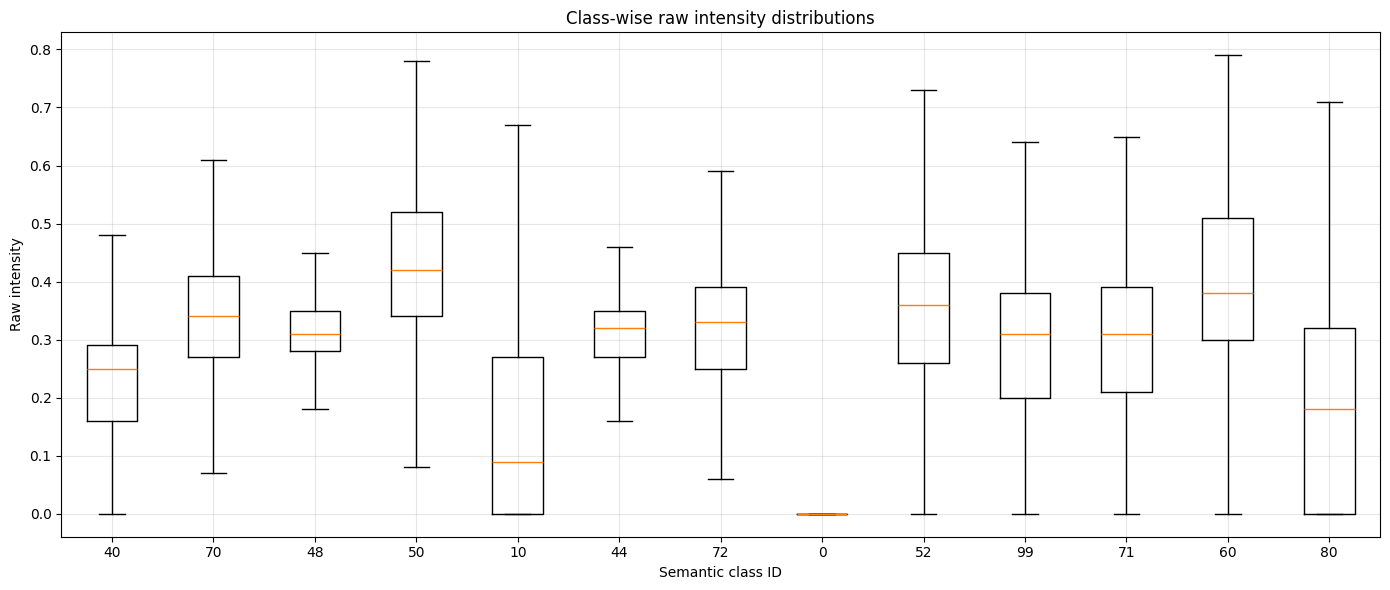

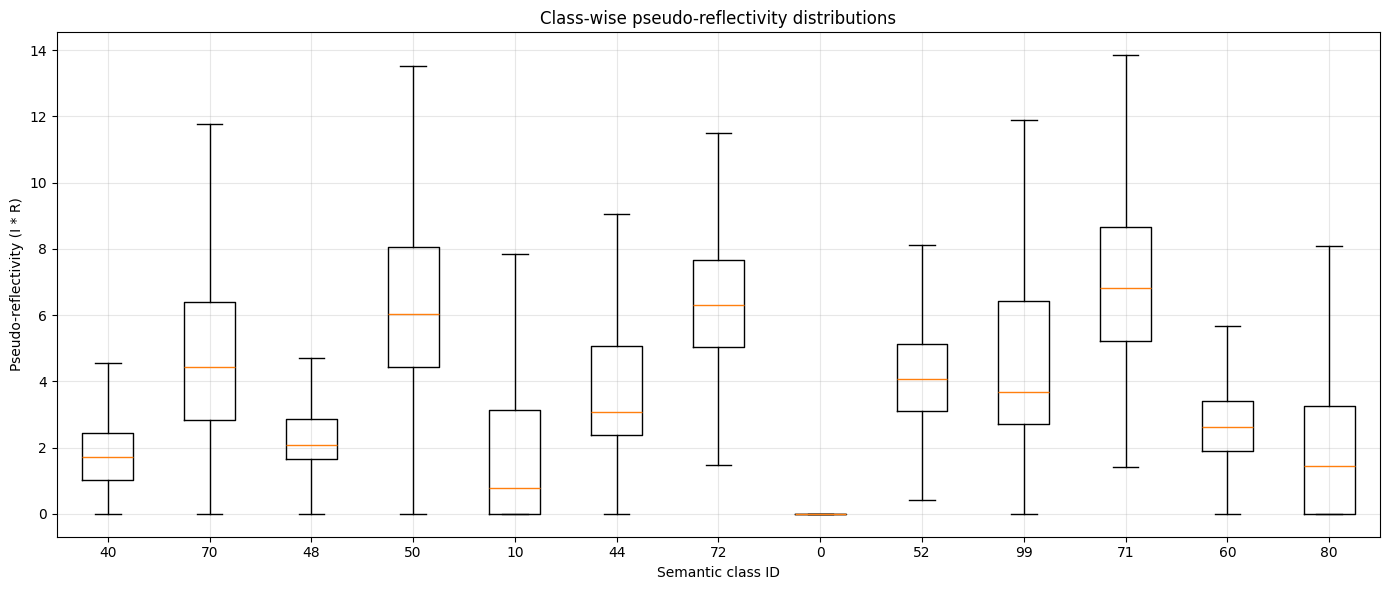

In [4]:
import matplotlib.pyplot as plt

# Keep classes in the same order as the stats table (sorted by count descending)
ordered_classes = class_stats_df["class_id"].tolist()

intensity_data = [intensity[semantic_labels == cls] for cls in ordered_classes]
pseudo_data = [pseudo_reflectivity[semantic_labels == cls] for cls in ordered_classes]
class_labels = [str(cls) for cls in ordered_classes]

plt.figure(figsize=(14, 6))
plt.boxplot(intensity_data, tick_labels=class_labels, showfliers=False)
plt.xlabel("Semantic class ID")
plt.ylabel("Raw intensity")
plt.title("Class-wise raw intensity distributions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.boxplot(pseudo_data, tick_labels=class_labels, showfliers=False)
plt.xlabel("Semantic class ID")
plt.ylabel("Pseudo-reflectivity (I * R)")
plt.title("Class-wise pseudo-reflectivity distributions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The boxplots make the class-wise behavior much clearer than the summary table alone.

Raw intensity already contains semantic structure, but many classes still overlap in similar value bands. In contrast, pseudo-reflectivity produces stronger vertical separation for several classes, suggesting that the simple range-aware proxy redistributes the signal in a more class-dependent way.

This does not prove physical reflectivity recovery. But it does support the practical hypothesis of this project: a lightweight intensity-range feature can expose semantic distinctions more clearly than raw intensity alone.

## Step 5: Quantify semantic separability across valid classes

The boxplots suggest that pseudo-reflectivity separates some classes more clearly than raw intensity.

Now we measure that directly using a simple Fisher-style class separability score across the valid semantic classes. This converts the visual impression into one compact number for:
- raw intensity, and
- pseudo-reflectivity.

In [5]:
import numpy as np

def fisher_style_multiclass_score(values, labels, classes):
    overall_mean = np.mean(values)

    between = 0.0
    within = 0.0

    for cls in classes:
        cls_vals = values[labels == cls]
        cls_mean = np.mean(cls_vals)
        cls_var = np.var(cls_vals)
        n_cls = len(cls_vals)

        between += n_cls * (cls_mean - overall_mean) ** 2
        within += n_cls * cls_var

    return between / within if within > 0 else np.nan

intensity_score = fisher_style_multiclass_score(intensity, semantic_labels, valid_classes)
pseudo_score = fisher_style_multiclass_score(pseudo_reflectivity, semantic_labels, valid_classes)

print("Multiclass semantic separability score")
print(f"Raw intensity          : {intensity_score:.6f}")
print(f"Pseudo-reflectivity    : {pseudo_score:.6f}")
print(f"Absolute improvement   : {pseudo_score - intensity_score:.6f}")
print(f"Relative improvement   : {(pseudo_score - intensity_score) / intensity_score:.6f}")

Multiclass semantic separability score
Raw intensity          : 0.448162
Pseudo-reflectivity    : 0.505541
Absolute improvement   : 0.057379
Relative improvement   : 0.128031


The semantic separability score confirms the visual impression from the boxplots.

Raw intensity already contains useful class information, but pseudo-reflectivity increases the multiclass separability score from `0.448` to `0.506`, which corresponds to an absolute improvement of about `0.057` and a relative improvement of about `12.8%`.

This is a modest but meaningful gain. It suggests that the range-aware proxy does not fully solve semantic overlap, but it does make the signal more discriminative across classes in this frame.

## Step 6: Visualize the frame spatially with semantics, intensity, and pseudo-reflectivity

So far we have compared class distributions numerically and statistically.

Now we return to the actual scene geometry and visualize the same frame in spatial form:
- semantic labels,
- raw intensity,
- and pseudo-reflectivity.

This helps us connect the signal statistics back to where those patterns live in the point cloud.

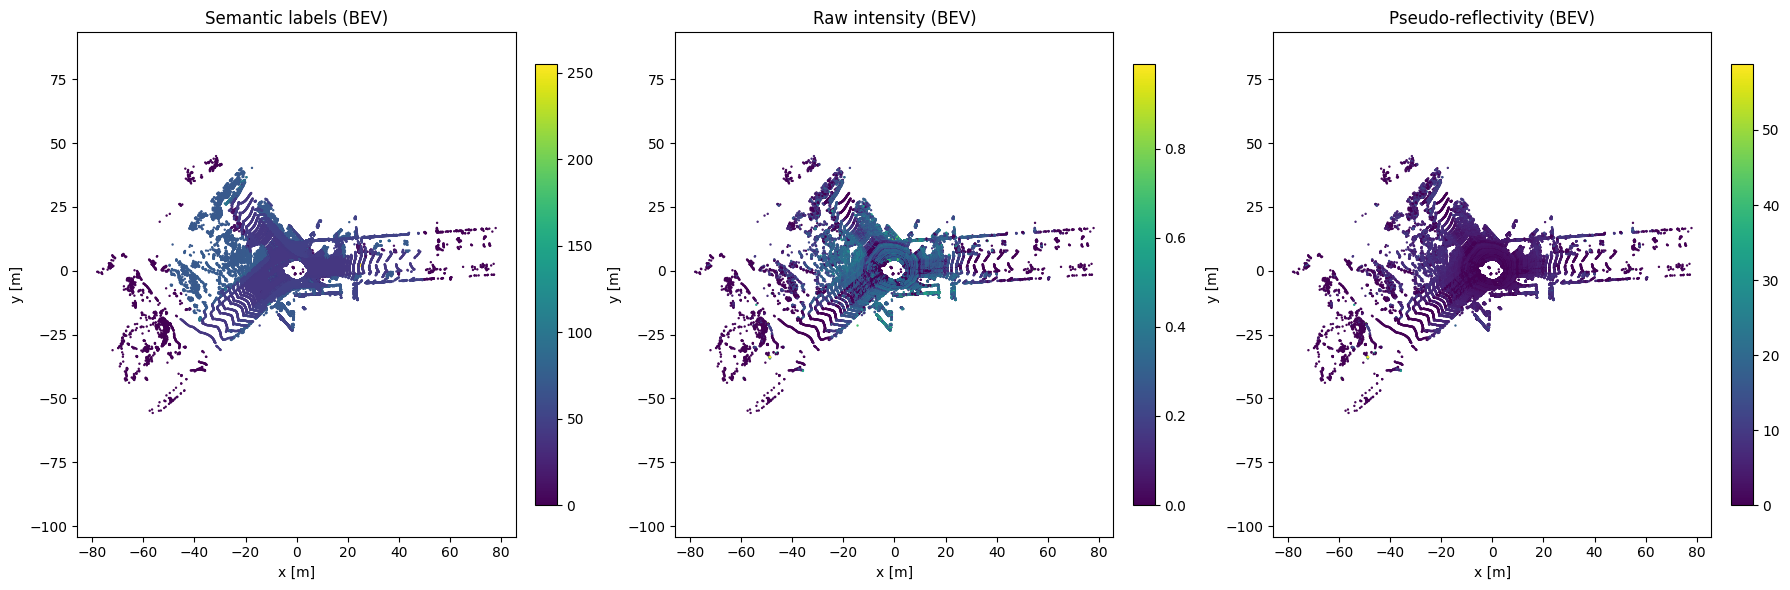

In [6]:
import matplotlib.pyplot as plt

# Bird's-eye view coordinates
x = xyz[:, 0]
y = xyz[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Semantic labels
sc0 = axes[0].scatter(x, y, c=semantic_labels, s=0.5)
axes[0].set_title("Semantic labels (BEV)")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].axis("equal")
plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)

# 2) Raw intensity
sc1 = axes[1].scatter(x, y, c=intensity, s=0.5)
axes[1].set_title("Raw intensity (BEV)")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
axes[1].axis("equal")
plt.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)

# 3) Pseudo-reflectivity
sc2 = axes[2].scatter(x, y, c=pseudo_reflectivity, s=0.5)
axes[2].set_title("Pseudo-reflectivity (BEV)")
axes[2].set_xlabel("x [m]")
axes[2].set_ylabel("y [m]")
axes[2].axis("equal")
plt.colorbar(sc2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

The spatial visualizations confirm that the semantic labels are well aligned with the LiDAR frame and that the signal patterns are not just statistical artifacts.

Raw intensity shows localized return-strength variation, but pseudo-reflectivity produces a different spatial emphasis across the scene. This supports the earlier class-wise analysis: the range-aware proxy is not merely rescaling the signal globally, but changing how different parts of the scene stand out.

## Step 7: Compare class mean values directly

After boxplots and global separability, we now make the class differences easier to read at a glance.

In this step, we plot the mean value of each valid semantic class for:
- raw intensity,
- range,
- and pseudo-reflectivity.

This gives a compact class-level comparison of where each signal places each semantic group.

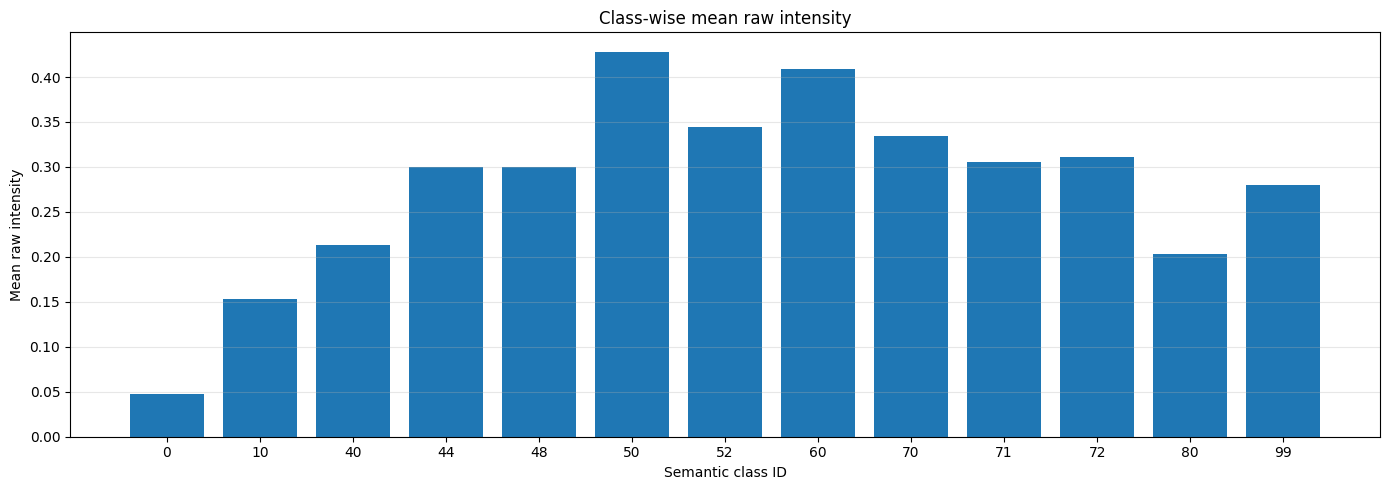

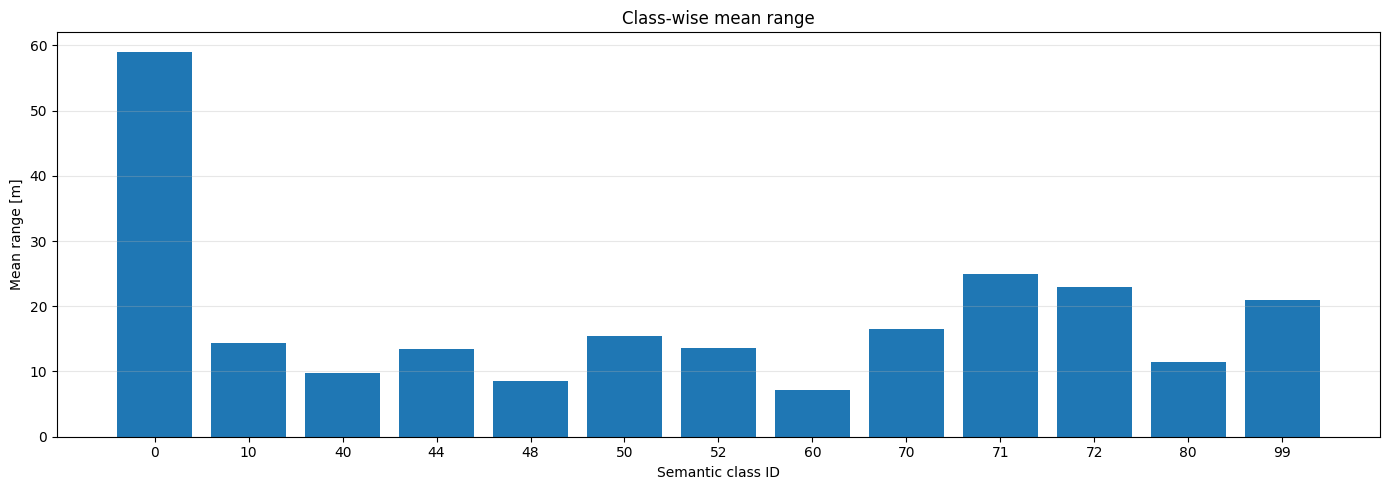

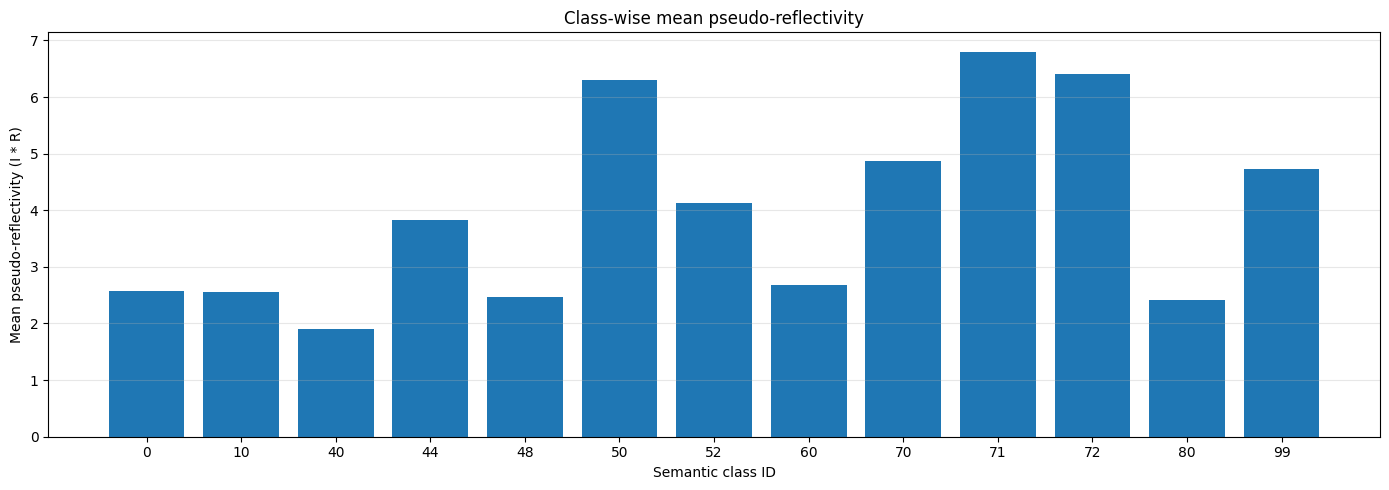

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = class_stats_df.sort_values("class_id").reset_index(drop=True)

class_ids = plot_df["class_id"].astype(str).tolist()
xpos = np.arange(len(class_ids))

plt.figure(figsize=(14, 5))
plt.bar(xpos, plot_df["intensity_mean"])
plt.xticks(xpos, class_ids)
plt.xlabel("Semantic class ID")
plt.ylabel("Mean raw intensity")
plt.title("Class-wise mean raw intensity")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(xpos, plot_df["range_mean"])
plt.xticks(xpos, class_ids)
plt.xlabel("Semantic class ID")
plt.ylabel("Mean range [m]")
plt.title("Class-wise mean range")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(xpos, plot_df["pseudo_mean"])
plt.xticks(xpos, class_ids)
plt.xlabel("Semantic class ID")
plt.ylabel("Mean pseudo-reflectivity (I * R)")
plt.title("Class-wise mean pseudo-reflectivity")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The class-mean plots make the signal transformation very clear.

Raw intensity and pseudo-reflectivity do not rank semantic classes in the same way. Some classes that appear strong in raw intensity become less prominent after range interaction, while others become more distinct in pseudo-reflectivity.

This reinforces the main point of the notebook: the range-aware proxy is not simply enlarging the raw signal, but changing the semantic ordering of classes in a meaningful way.

## Step 8: Write the final notebook takeaway

We now have enough evidence from:
- class counts,
- class-wise summary statistics,
- distribution plots,
- separability scores,
- spatial visualizations,
- and class-mean comparisons.

This final cell records the main conclusion of Notebook 04 in a compact, honest form.

In [8]:
print("NOTEBOOK 04: FINAL SEMANTIC SUMMARY\n")

print("[Semantic Frame Composition]")
print(f"number of unique semantic classes     = {len(unique_classes)}")
print(f"valid classes used for analysis       = {len(valid_classes)}")
print(f"valid class IDs                       = {valid_classes.tolist()}")
print()

print("[Multiclass Semantic Separability]")
print(f"raw intensity score                   = {intensity_score:.6f}")
print(f"pseudo-reflectivity score             = {pseudo_score:.6f}")
print(f"absolute improvement                  = {pseudo_score - intensity_score:.6f}")
print(f"relative improvement                  = {(pseudo_score - intensity_score) / intensity_score:.6f}")
print()

top_intensity = class_stats_df.sort_values("intensity_mean", ascending=False).head(3)[["class_id", "intensity_mean"]]
top_pseudo = class_stats_df.sort_values("pseudo_mean", ascending=False).head(3)[["class_id", "pseudo_mean"]]
top_range = class_stats_df.sort_values("range_mean", ascending=False).head(3)[["class_id", "range_mean"]]

print("[Top 3 Classes by Mean Raw Intensity]")
for _, row in top_intensity.iterrows():
    print(f"class {int(row['class_id']):>3} : {row['intensity_mean']:.6f}")
print()

print("[Top 3 Classes by Mean Pseudo-Reflectivity]")
for _, row in top_pseudo.iterrows():
    print(f"class {int(row['class_id']):>3} : {row['pseudo_mean']:.6f}")
print()

print("[Top 3 Classes by Mean Range]")
for _, row in top_range.iterrows():
    print(f"class {int(row['class_id']):>3} : {row['range_mean']:.6f}")
print()

print("[Conclusion]")
print("Raw intensity already carries semantic structure, but the I * R proxy")
print("reorganizes class behavior in a way that produces modestly stronger")
print("multiclass separability on this frame. This does not constitute true")
print("reflectivity calibration, but it does support the practical use of")
print("range-aware signal augmentation for semantic LiDAR analysis.")

NOTEBOOK 04: FINAL SEMANTIC SUMMARY

[Semantic Frame Composition]
number of unique semantic classes     = 17
valid classes used for analysis       = 13
valid class IDs                       = [0, 10, 40, 44, 48, 50, 52, 60, 70, 71, 72, 80, 99]

[Multiclass Semantic Separability]
raw intensity score                   = 0.448162
pseudo-reflectivity score             = 0.505541
absolute improvement                  = 0.057379
relative improvement                  = 0.128031

[Top 3 Classes by Mean Raw Intensity]
class  50 : 0.428269
class  60 : 0.408528
class  52 : 0.344582

[Top 3 Classes by Mean Pseudo-Reflectivity]
class  71 : 6.802622
class  72 : 6.411902
class  50 : 6.293034

[Top 3 Classes by Mean Range]
class   0 : 59.040615
class  71 : 24.887270
class  72 : 22.927259

[Conclusion]
Raw intensity already carries semantic structure, but the I * R proxy
reorganizes class behavior in a way that produces modestly stronger
multiclass separability on this frame. This does not constitute t

## Front-view semantic visualization with class-name annotations

This step creates a forward field-of-view semantic scatter plot and writes class names directly on the scene.

For each semantic class visible in the front view, we place one text label near the median position of that class in the plot. This gives a quick human-readable semantic snapshot of what is where in front of the sensor.

Annotated FOV classes and chosen cluster sizes:
Class  10 (car): 3220 points, largest cluster = 37 grid cells
Class  51 (fence): 370 points, largest cluster = 47 grid cells
Class  71 (trunk): 776 points, largest cluster = 25 grid cells
Class  80 (pole): 389 points, largest cluster = 5 grid cells
Class  99 (other-object): 474 points, largest cluster = 9 grid cells


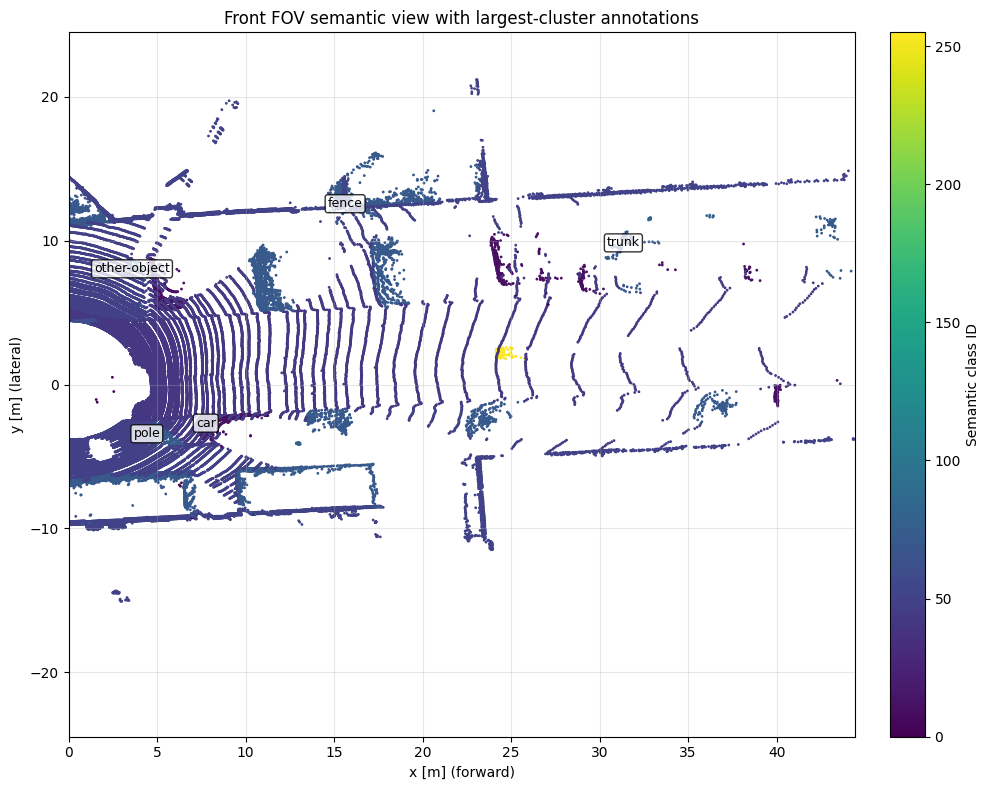

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# SemanticKITTI names for classes that may appear here
SEMANTIC_NAME_MAP = {
    0: "unlabeled",
    1: "outlier",
    10: "car",
    11: "bicycle",
    13: "bus",
    15: "motorcycle",
    16: "on-rails",
    18: "truck",
    20: "other-vehicle",
    30: "person",
    31: "bicyclist",
    32: "motorcyclist",
    40: "road",
    44: "parking",
    48: "sidewalk",
    49: "other-ground",
    50: "building",
    51: "fence",
    52: "other-structure",
    60: "lane-marking",
    70: "vegetation",
    71: "trunk",
    72: "terrain",
    80: "pole",
    81: "traffic-sign",
    99: "other-object",
    252: "moving-car",
    253: "moving-bicyclist",
    254: "moving-person",
    255: "moving-motorcyclist",
    256: "moving-on-rails",
    257: "moving-bus",
    258: "moving-truck",
    259: "moving-other-vehicle",
}

# Fixed FOV limits
x_min, x_max = 0.0, 44.437
y_min, y_max = -24.467, 24.467

fov_mask = (
    (xyz[:, 0] >= x_min) & (xyz[:, 0] <= x_max) &
    (xyz[:, 1] >= y_min) & (xyz[:, 1] <= y_max)
)

x_fov = xyz[fov_mask, 0]
y_fov = xyz[fov_mask, 1]
sem_fov = semantic_labels[fov_mask]

# Classes we want to annotate in-scene
ANNOTATE_CLASSES = {10, 51, 71, 80, 81, 99}
MIN_FOV_POINTS_FOR_TEXT = 80

# Cluster parameters in BEV
GRID_SIZE = 0.35   # meters per cell
MIN_CLUSTER_CELLS = 3

def largest_connected_component_centroid(x_vals, y_vals, grid_size=0.35, min_cluster_cells=3):
    """
    Rasterize points to a 2D occupancy grid, find connected components on occupied cells,
    pick the largest component, and return its centroid in world coordinates.
    """
    if len(x_vals) == 0:
        return None

    # Quantize points into grid cells
    ix = np.floor((x_vals - x_min) / grid_size).astype(int)
    iy = np.floor((y_vals - y_min) / grid_size).astype(int)

    occupied = set(zip(ix, iy))
    visited = set()
    components = []

    # 8-connected neighborhood
    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 ( 0, -1),          ( 0, 1),
                 ( 1, -1), ( 1, 0), ( 1, 1)]

    for cell in occupied:
        if cell in visited:
            continue

        stack = [cell]
        visited.add(cell)
        comp = []

        while stack:
            cx, cy = stack.pop()
            comp.append((cx, cy))

            for dx, dy in neighbors:
                nxt = (cx + dx, cy + dy)
                if nxt in occupied and nxt not in visited:
                    visited.add(nxt)
                    stack.append(nxt)

        if len(comp) >= min_cluster_cells:
            components.append(comp)

    # Fallback if no component survives threshold
    if len(components) == 0:
        return float(np.median(x_vals)), float(np.median(y_vals)), 1

    largest = max(components, key=len)
    largest_set = set(largest)

    # Keep only points whose rasterized cells belong to the largest component
    point_mask = np.array([(a, b) in largest_set for a, b in zip(ix, iy)])
    x_cluster = x_vals[point_mask]
    y_cluster = y_vals[point_mask]

    if len(x_cluster) == 0:
        return float(np.median(x_vals)), float(np.median(y_vals)), len(largest)

    return float(np.median(x_cluster)), float(np.median(y_cluster)), len(largest)

plt.figure(figsize=(10, 8))
sc = plt.scatter(x_fov, y_fov, c=sem_fov, s=1.0)
plt.xlabel("x [m] (forward)")
plt.ylabel("y [m] (lateral)")
plt.title("Front FOV semantic view with largest-cluster annotations")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True, alpha=0.3)

fov_classes, fov_counts = np.unique(sem_fov, return_counts=True)

print("Annotated FOV classes and chosen cluster sizes:")

for cls, cnt in zip(fov_classes, fov_counts):
    if cls not in ANNOTATE_CLASSES:
        continue
    if cnt < MIN_FOV_POINTS_FOR_TEXT:
        continue

    cls_mask = sem_fov == cls
    x_cls = x_fov[cls_mask]
    y_cls = y_fov[cls_mask]

    result = largest_connected_component_centroid(
        x_cls, y_cls,
        grid_size=GRID_SIZE,
        min_cluster_cells=MIN_CLUSTER_CELLS
    )

    if result is None:
        continue

    x_text, y_text, cluster_cells = result
    class_name = SEMANTIC_NAME_MAP.get(int(cls), f"class-{int(cls)}")

    plt.text(
        x_text,
        y_text,
        class_name,
        fontsize=9,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
    )

    print(f"Class {int(cls):>3} ({class_name}): {cnt} points, largest cluster = {cluster_cells} grid cells")

plt.colorbar(sc, fraction=0.046, pad=0.04, label="Semantic class ID")
plt.tight_layout()
plt.show()

### Observation

Annotating semantic class names directly inside the front-view scene is only reliable when label placement is tied to local spatial structure.

Using the largest connected cluster for each selected class produces more meaningful in-scene annotations than using the global class median. This makes compact or localized classes such as cars, poles, and trunks visually interpretable, while broad surface classes remain better represented by color alone.

## Final Conclusion

This notebook extended the earlier reflectivity analysis from global signal behavior to direct semantic interpretation on a single SemanticKITTI frame.

The frame contained meaningful semantic diversity, with 17 total classes present and 13 classes retained for reliable class-wise analysis. Across these classes, raw intensity already showed nontrivial semantic structure, but the range-aware pseudo-reflectivity proxy `I * R` produced a clearer redistribution of class behavior. This was visible in the summary statistics, in the boxplot distributions, and in the class-mean comparisons.

Quantitatively, the multiclass semantic separability score increased from `0.448162` for raw intensity to `0.505541` for pseudo-reflectivity, corresponding to an absolute improvement of `0.057379` and a relative improvement of about `12.8%`. This is not a dramatic leap, but it is a consistent and meaningful gain. It suggests that the proxy does not merely rescale intensity, but changes the class geometry of the signal in a way that is more semantically informative.

The BEV visualizations and front-FOV semantic view further supported this interpretation by showing that the observed differences are spatially grounded in the scene rather than being only statistical artifacts. At the same time, this notebook remained honest about scope: `I * R` is not calibrated physical reflectivity, and this analysis does not claim a full semantic segmentation method or a universally valid reflectance model.

Overall, the main takeaway is clear:

**Raw LiDAR intensity already contains some semantic information, but a simple range-aware pseudo-reflectivity proxy can make that information modestly more discriminative and more interpretable at the class level on this frame.**

This makes pseudo-reflectivity a practically useful augmentation signal for the next stage of the project, especially when moving from single-frame analysis toward multi-frame semantic consistency over motion.

---